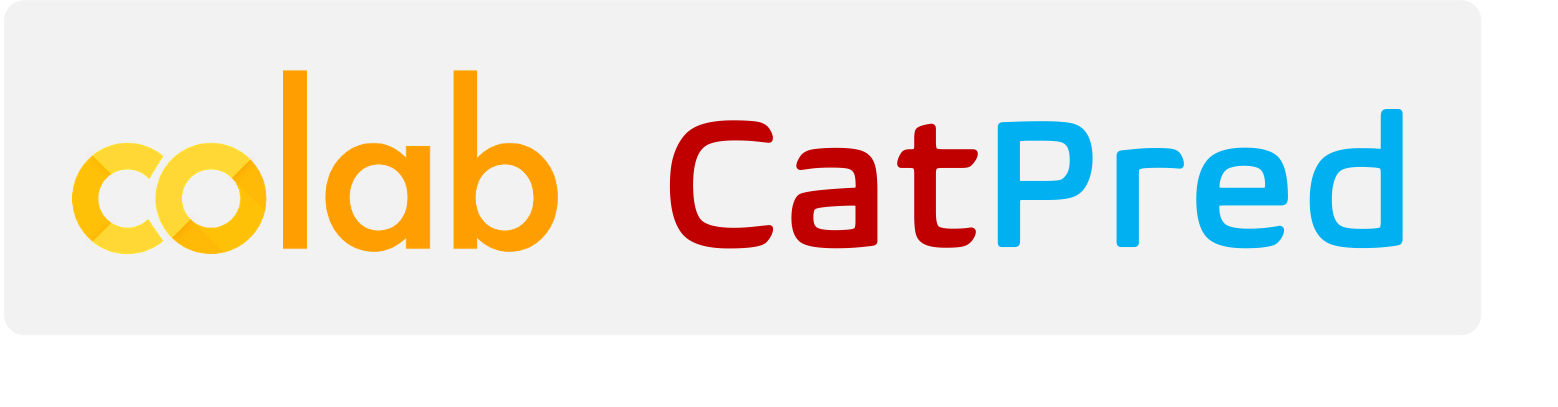
# CatPred: Prediction of Enzyme-Substrate $k_{cat}$, $K_{m}$ and Enzyme-Inhibitor $K_{i}$

```markdown
This notebook runs the CatPred models for enzyme kinetic parameter prediction. The pipeline processes enzyme sequences into the ESM2 language model encodings and reactant SMILES strings into 2d graphs and inputs to the pretrained CatPred models. Output from CatPred is the kinetic parameter prediction along with the attached prediction uncertainities.

By default, the notebook runs on an example enzyme sequence and substrate, edit them to your own inputs and "Run" each cell by clicking the ▶ icon to the left of each cell
```
---
**Inputs**
1. Enzyme sequence - the aminoacid sequence of the enzyme (in capital letters with no spaces)
2. Substrate/Inhibitor canonical SMILES string for $K_{m}$ and $K_{i}$<br>
(OR)<br>
Concatenated SMILES string of all reactants for $k_{cat}$. Use "." character for concatenation.
---
**Outputs**

$k_{cat}$ or $K_{m}$ or $K_{i}$ prediction and their estimated standard deviation values. <br>

---

More information is available on https://github.com/maranasgroup/catpred/

## CatPred: Setup (~15 mins)

In [ ]:
#@title Install CatPred and download trained models (~10 min)

!wget -c https://repo.anaconda.com/archive/Anaconda3-2024.10-1-Linux-x86_64.sh
!chmod +x Anaconda3-2024.10-1-Linux-x86_64.sh
!bash ./Anaconda3-2024.10-1-Linux-x86_64.sh -b -f -p /usr/local

!wget https://catpred.s3.us-east-1.amazonaws.com/pretrained_production.tar.gz -q
!tar -xzf pretrained_production.tar.gz
!wget https://catpred.s3.amazonaws.com/processed_databases.tar.gz -q
!tar -xzf processed_databases.tar.gz

!git clone https://github.com/maranasgroup/CatPred.git

%cd CatPred/
!conda env create -f ./environment.yml -q
!source activate catpred; pip install -e . -q

import sys
sys.path.append('/usr/local/envs/catpred/lib/python3.9/site-packages')


In [2]:
#@title Load processed BRENDA database

import pandas as pd
import numpy as np
from rdkit import Chem
from google.colab import data_table
data_table.enable_dataframe_formatter()

# Disable RDKit logging
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

def run_once(func):
    def wrapper(*args, **kwargs):
        if not wrapper.has_run:
            wrapper.result = func(*args, **kwargs)
            wrapper.has_run = True
        return wrapper.result
    wrapper.has_run = False
    return wrapper

@run_once
def load_brenda_data(file_path: str) -> pd.DataFrame:
    """
    Load the BRENDA database from a CSV file.

    Args:
        file_path (str): Path to the BRENDA CSV file.

    Returns:
        pd.DataFrame: The loaded BRENDA database.
    """
    return pd.read_csv(file_path)

def preprocess_reaction_smiles(reaction_smiles: str) -> str:
    """
    Preprocess a reaction SMILES string by splitting it into reactants,
    sorting them, and canonicalizing them using RDKit.

    Args:
        reaction_smiles (str): The reaction SMILES string.

    Returns:
        str: The preprocessed reactant SMILES string.
    """
    if not pd.isna(reaction_smiles):
        reactants = reaction_smiles.split('>>')[0]
        if '.' in reactants:
            reactant_list = reactants.split('.')
            reactant_list = sorted(reactant_list)
            canonicalized_reactants = []
            for reactant in reactant_list:
                try:
                    mol = Chem.MolFromSmiles(reactant)
                    canonicalized_reactants.append(Chem.MolToSmiles(mol, isomericSmiles=False))
                except:
                    canonicalized_reactants.append(reactant)
            reactants = '.'.join(canonicalized_reactants)
        return reactants
    else:
        return 'None'

@run_once
def create_input_strings_brenda(brenda_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create input strings for kcat and kmki predictions.

    Args:
        brenda_df (pd.DataFrame): The BRENDA database.

    Returns:
        pd.DataFrame: The BRENDA database with input strings.
    """
    brenda_df['reactant_smiles'] = brenda_df['reaction_smiles'].apply(preprocess_reaction_smiles)
    brenda_df['input_str_kcat'] = brenda_df['sequence'] + np.array(['__']*len(brenda_df)) + brenda_df['reactant_smiles']
    brenda_df['input_str_kmki'] = brenda_df['sequence'] + np.array(['__']*len(brenda_df)) + brenda_df['substrate_smiles']
    return brenda_df

def find_matches_brenda(brenda_df: pd.DataFrame, input_smi: str, seq: str, parameter: str) -> pd.DataFrame:
    """
    Find matches in the BRENDA database for a given input SMILES string and sequence.

    Args:
        brenda_df (pd.DataFrame): The BRENDA database.
        input_smi (str): The input SMILES string.
        seq (str): The sequence.
        parameter (str): The parameter to search for (kcat, km, or ki).

    Returns:
        pd.DataFrame: The matched rows from the BRENDA database.
    """
    input_smi = preprocess_reaction_smiles(input_smi)
    input_str = seq + '__' + input_smi
    if parameter == 'kcat':
        input_header = 'input_str_kcat'
        label_header = 'turnover_number'
    else:
        input_header = 'input_str_kmki'
        if parameter == 'km':
            label_header = 'km_value'
        else:
            label_header = 'ki_value'
    matched = brenda_df[brenda_df[input_header] == input_str]
    matched_values = matched[matched['parameter'] == label_header]
    return matched_values

def find_matches_brenda_seq(brenda_df: pd.DataFrame, seq: str) -> pd.DataFrame:
    """
    Find matches in the BRENDA database for a given input SMILES string and sequence.

    Args:
        brenda_df (pd.DataFrame): The BRENDA database.
        seq (str): The sequence.

    Returns:
        pd.DataFrame: The matched rows from the BRENDA database.
    """
    input_str = seq
    label_header = 'turnover_number'
    matched = brenda_df[brenda_df['sequence'] == input_str]
    matched_values = matched[matched['parameter'] == label_header]

    return matched_values

def display_matches_brenda(matched_values: pd.DataFrame, parameter: str) -> None:
    """
    Display the matched rows from the BRENDA database.

    Args:
        matched_values (pd.DataFrame): The matched rows.
        parameter (str): The parameter to display (kcat, km, or ki).
    """
    display_cols_brenda = ['organism', 'ec', 'substrate', 'parameter', 'value', 'ph', 'temperature', 'comment']
    if parameter.lower() == 'kcat':
        display_cols_brenda.append('reaction_smiles')
    elif parameter.lower() == 'km' or parameter.lower() == 'ki':
        display_cols_brenda.append('substrate_smiles')

    print(f'Found {len(matched_values)} occurrences of input in BRENDA:')
    if len(matched_values) > 0:
        display(matched_values[display_cols_brenda])

# Load the BRENDA database
brenda_df = load_brenda_data('../processed_databases/brenda.csv')

# Create input strings
brenda_df = create_input_strings_brenda(brenda_df)

In [3]:
#@title Load processed SABIO-RK database


import pandas as pd
import numpy as np
from rdkit import Chem
from google.colab import data_table
data_table.enable_dataframe_formatter()

def run_once(func):
    def wrapper(*args, **kwargs):
        if not wrapper.has_run:
            wrapper.result = func(*args, **kwargs)
            wrapper.has_run = True
        return wrapper.result
    wrapper.has_run = False
    return wrapper

@run_once
def load_sabio_data(file_path: str) -> pd.DataFrame:
    """
    Load the SABIO-RK database from a CSV file.

    Args:
        file_path (str): Path to the SABIO-RK CSV file.

    Returns:
        pd.DataFrame: The loaded SABIO-RK database.
    """
    return pd.read_csv(file_path, low_memory=False)


@run_once
def create_input_strings_sabio(sabio_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create input strings for kcat and kmki predictions.

    Args:
        sabio_df (pd.DataFrame): The SABIO-RK database.

    Returns:
        pd.DataFrame: The SABIO-RK database with input strings.
    """
    sabio_df['reactant_smiles'] = sabio_df['reaction_smiles'].apply(preprocess_reaction_smiles)
    sabio_df['input_str_kcat'] = sabio_df['sequence'] + np.array(['__']*len(sabio_df)) + sabio_df['reactant_smiles']
    sabio_df['input_str_kmki'] = sabio_df['sequence'] + np.array(['__']*len(sabio_df)) + sabio_df['param_species_smiles']
    return sabio_df


def find_matches_sabio(sabio_df: pd.DataFrame, input_smi: str, seq: str, parameter: str) -> pd.DataFrame:
    """
    Find matches in the SABIO-RK database for a given input SMILES string and sequence.

    Args:
        sabio_df (pd.DataFrame): The SABIO-RK database.
        input_smi (str): The input SMILES string.
        seq (str): The sequence.
        parameter (str): The parameter to search for (kcat, km, or ki).

    Returns:
        pd.DataFrame: The matched rows from the SABIO-RK database.
    """
    input_smi = preprocess_reaction_smiles(input_smi)
    input_str = seq + '__' + input_smi
    if parameter == 'kcat':
        input_header = 'input_str_kcat'
        label_header = 'kcat'
    else:
        input_header = 'input_str_kmki'
        if parameter == 'km':
            label_header = 'Km'
        else:
            label_header = 'Ki'
    matched = sabio_df[sabio_df[input_header] == input_str]
    matched_values = matched[matched['param_name'] == label_header]
    return matched_values

def display_matches_sabio(matched_values: pd.DataFrame, parameter: str) -> None:
    """
    Display the matched rows from the SABIO-RK database.

    Args:
        matched_values (pd.DataFrame): The matched rows.
        parameter (str): The parameter to display (kcat, km, or ki).
    """
    display_cols_sabio = ['species', 'ec', 'param_species_name', 'param_name', 'param_value', 'ph', 'temperature', 'pubmed_id']
    if parameter.lower() == 'kcat':
        display_cols_sabio.append('reaction_smiles')
    elif parameter.lower() == 'km' or parameter.lower() == 'ki':
        display_cols_sabio.append('param_species_smiles')

    print(f'Found {len(matched_values)} occurrences of input in SABIO-RK:')
    if len(matched_values) > 0:
        display(matched_values[display_cols_sabio])

# Load the SABIO-RK database
sabio_df = load_sabio_data('../processed_databases/sabio.csv')

# Create input strings
sabio_df = create_input_strings_sabio(sabio_df)

## CatPred: $k_{cat}$ example

In [ ]:
#@title Get prediction:
parameter = 'kcat' # @param ["kcat", "Km", "Ki"] {allow-input: true}
parameter = parameter.lower()

import sys
from pathlib import Path

import pandas as pd
from IPython.display import display, Math
from rdkit import Chem
from rdkit.Chem.Draw.IPythonConsole import ShowMols

from catpred.inference import PredictionRequest, run_prediction_pipeline

uniprot_id = "P35557" #@param {type:"string"}
#@markdown If you do not have a uniprot-id, enter some name (for eg: "enzyme1")
sequence = 'MLDDRARMEAAKKEKVEQILAEFQLQEEDLKKVMRRMQKEMDRGLRLETHEEASVKMLPTYVRSTPEGSEVGDFLSLDLGGTNFRVMLVKVGEGEEGQWSVKTKHQMYSIPEDAMTGTAEMLFDYISECISDFLDKHQMKHKKLPLGFTFSFPVRHEDIDKGILLNWTKGFKASGAEGNNVVGLLRDAIKRRGDFEMDVVAMVNDTVATMISCYYEDHQCEVGMIVGTGCNACYMEEMQNVELVEGDEGRMCVNTEWGAFGDSGELDEFLLEYDRLVDESSANPGQQLYEKLIGGKYMGELVRLVLLRLVDENLLFHGEASEQLRTRGAFETRFVSQVESDTGDRKQIYNILSTLGLRPSTTDCDIVRRACESVSTRAAHMCSAGLAGVINRMRESRSEDVMRITVGVDGSVYKLHPSFKERFHASVRRLTPSCEITFIESEEGSGRGAALVSAVACKKACMLGQ' #@param {type:"string"}
SMILES = "C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O.C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O)(O)OP(=O)(O)OP(=O)(O)O)O)O)N " #@param {type:"string"}


def run_colab_prediction(parameter, uni, seq, smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print('Invalid SMILES input!')
        print('Correct your input! Exiting..')
        return None

    smi = Chem.MolToSmiles(mol)
    valid_aas = set('ACDEFGHIKLMNPQRSTVWY')
    if not set(seq).issubset(valid_aas):
        print('Invalid Enzyme sequence input!')
        print('Correct your input! Exiting..')
        return None

    input_file = Path(f'{uni}_{parameter}.csv')
    input_df = pd.DataFrame([
        {
            'name': uni,
            'sequence': seq,
            'SMILES': smi,
            'pdbpath': f'{uni}.pdb',
        }
    ])
    input_df.to_csv(input_file, index=False)

    print('Input success!')
    print('Enzyme sequence length:', len(seq))
    print('Substrate structure:')
    display(ShowMols([mol]))

    checkpoint_dir = f'../pretrained/production/{parameter}'
    request = PredictionRequest(
        parameter=parameter,
        input_file=str(input_file),
        checkpoint_dir=checkpoint_dir,
        repo_root='.',
        python_executable='/usr/local/envs/catpred/bin/python',
    )

    print('Predicting.. This will take a minute or so...\n')
    outfile = run_prediction_pipeline(request=request, results_dir='results')
    df = pd.read_csv(outfile)

    if parameter == 'kcat':
        parameter_print, parameter_print_log = 'k_{cat}', 'log_{10}(k_{cat})'
        target_col, unit = 'log10kcat_max', ' s^{-1}'
    elif parameter == 'km':
        parameter_print, parameter_print_log = 'K_{m}', 'log_{10}(K_{m})'
        target_col, unit = 'log10km_mean', ' mM'
    else:
        parameter_print, parameter_print_log = 'K_{i}', 'log_{10}(K_{i})'
        target_col, unit = 'log10ki_mean', ' mM'

    unc_col = f'{target_col}_mve_uncal_var'
    model_cols = [col for col in df.columns if col.startswith(target_col) and 'model_' in col]

    unc = df[unc_col].iloc[0]
    prediction = df[target_col].iloc[0]
    prediction_linear = 10 ** prediction
    model_outs = [df[col].iloc[0] for col in model_cols]
    epi_unc = float(pd.Series(model_outs).var(ddof=0)) if model_outs else 0.0
    alea_unc = max(float(unc) - epi_unc, 0.0)

    print('Prediction successful!\n')
    print('Result:\n')
    display(Math((parameter_print + f' = {prediction_linear:.5f}' + unit)))
    print('\n')
    display(Math((parameter_print_log + f' = {prediction:.5f}')))
    display(Math(('SD_{total}' + f' = {(float(unc) ** 0.5):.5f}')))
    display(Math(('SD_{aleatoric}' + f' = {(alea_unc ** 0.5):.5f}')))
    display(Math(('SD_{epistemic}' + f' = {(epi_unc ** 0.5):.5f}')))

    return df

output_df = run_colab_prediction(parameter, uniprot_id, sequence, SMILES)
output_df


In [24]:
#@title Get BRENDA matches

# Find matches
input_smi = preprocess_reaction_smiles(smi)
seq = seq
parameter = parameter
matched_values = find_matches_brenda(brenda_df, input_smi, seq, parameter)

# Display matches
display_matches_brenda(matched_values, parameter)

Found 3 occurrences of input in BRENDA:


,organism,ec,substrate,parameter,value,ph,temperature,comment,reaction_smiles
32800,Homo sapiens,2.7.1.1,D-glucose,turnover_number,40.1,8.6,33.0,"#87# wild-type, pH 7.6, 25 °C <240>",C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H...
32801,Homo sapiens,2.7.1.1,D-glucose,turnover_number,60.4,7.4,37.0,"#87# wild type enzyme, in 25 mM HEPES (pH 7.4)...",C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H...
32802,Homo sapiens,2.7.1.1,D-glucose,turnover_number,62.8,8.6,33.0,"#87# pH 7.1, temperature not specified in the ...",C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H...


In [25]:
#@title Get SABIO-RK matches

# Find matches
input_smi = preprocess_reaction_smiles(smi)
seq = seq
parameter = parameter
matched_values = find_matches_sabio(sabio_df, input_smi, seq, parameter)

# Display matches
display_matches_sabio(matched_values, parameter)

Found 15 occurrences of input in SABIO-RK:


,species,ec,param_species_name,param_name,param_value,ph,temperature,pubmed_id,reaction_smiles
25241,Homo sapiens,2.7.1.2,NaN,kcat,66.4,7.5,30.0,7742312.0,OCC1OC(O)C(O)C(O)C1O.Nc1ncnc2c1ncn2C1OC(COP(=O...
25250,Homo sapiens,2.7.1.2,NaN,kcat,56.4,7.5,30.0,7742312.0,OCC1OC(O)C(O)C(O)C1O.Nc1ncnc2c1ncn2C1OC(COP(=O...
25255,Homo sapiens,2.7.1.2,N-Acetyl-D-glucosamine,kcat,66.4,7.5,30.0,7742312.0,OCC1OC(O)C(O)C(O)C1O.Nc1ncnc2c1ncn2C1OC(COP(=O...
25259,Homo sapiens,2.7.1.2,alpha-D-Mannoheptulopyranose,kcat,66.4,7.5,30.0,7742312.0,OCC1OC(O)C(O)C(O)C1O.Nc1ncnc2c1ncn2C1OC(COP(=O...
25270,Homo sapiens,2.7.1.2,ATP,kcat,62.3,7.4,30.0,15677479.0,OCC1OC(O)C(O)C(O)C1O.Nc1ncnc2c1ncn2C1OC(COP(=O...
25272,Homo sapiens,2.7.1.2,ATP,kcat,62.3,7.4,30.0,15677479.0,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)OP(=O)(O)OP(=O)(O...
25274,Homo sapiens,2.7.1.2,D-Glucose,kcat,66.7,NaN,30.0,7961659.0,OCC1OC(O)C(O)C(O)C1O.Nc1ncnc2c1ncn2C1OC(COP(=O...
25276,Homo sapiens,2.7.1.2,D-Glucose,kcat,56.0,7.5,30.0,7961659.0,OCC1OC(O)C(O)C(O)C1O.Nc1ncnc2c1ncn2C1OC(COP(=O...
25282,Homo sapiens,2.7.1.2,D-Glucosamine,kcat,66.4,NaN,30.0,7961659.0,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)OP(=O)(O)OP(=O)(O...
25287,Homo sapiens,2.7.1.2,D-Glucose,kcat,66.4,NaN,30.0,7961659.0,OCC1OC(O)C(O)C(O)C1O.Nc1ncnc2c1ncn2C1OC(COP(=O...


## CatPred: $K_{m}$ example

In [ ]:
#@title Get prediction:
parameter = 'Km' # @param ["kcat", "Km", "Ki"] {allow-input: true}
parameter = parameter.lower()

uniprot_id = "P35557" #@param {type:"string"}
#@markdown If you do not have a uniprot-id, enter some name (for eg: "enzyme1")
sequence = 'MLDDRARMEAAKKEKVEQILAEFQLQEEDLKKVMRRMQKEMDRGLRLETHEEASVKMLPTYVRSTPEGSEVGDFLSLDLGGTNFRVMLVKVGEGEEGQWSVKTKHQMYSIPEDAMTGTAEMLFDYISECISDFLDKHQMKHKKLPLGFTFSFPVRHEDIDKGILLNWTKGFKASGAEGNNVVGLLRDAIKRRGDFEMDVVAMVNDTVATMISCYYEDHQCEVGMIVGTGCNACYMEEMQNVELVEGDEGRMCVNTEWGAFGDSGELDEFLLEYDRLVDESSANPGQQLYEKLIGGKYMGELVRLVLLRLVDENLLFHGEASEQLRTRGAFETRFVSQVESDTGDRKQIYNILSTLGLRPSTTDCDIVRRACESVSTRAAHMCSAGLAGVINRMRESRSEDVMRITVGVDGSVYKLHPSFKERFHASVRRLTPSCEITFIESEEGSGRGAALVSAVACKKACMLGQ' #@param {type:"string"}
SMILES = "C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O" #@param {type:"string"}

output_df = run_colab_prediction(parameter, uniprot_id, sequence, SMILES)
output_df


In [18]:
#@title Get BRENDA matches

# Find matches
input_smi = preprocess_reaction_smiles(smi)
seq = seq
parameter = parameter
matched_values = find_matches_brenda(brenda_df, input_smi, seq, parameter)

# Display matches
display_matches_brenda(matched_values, parameter)

Found 1 occurrences of input in BRENDA:


,organism,ec,substrate,parameter,value,ph,temperature,comment,substrate_smiles
32699,Homo sapiens,2.7.1.1,D-glucose,km_value,6.3,8.6,33.0,"#87# wild-type, K0.5 value, Hill coefficient 1...",OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O


In [19]:
#@title Get SABIO-RK matches

# Find matches
input_smi = preprocess_reaction_smiles(smi)
seq = seq
parameter = parameter
matched_values = find_matches_sabio(sabio_df, input_smi, seq, parameter)

# Display matches
display_matches_sabio(matched_values, parameter)

Found 0 occurrences of input in SABIO-RK:


## CatPred: $K_{i}$ example

In [ ]:
#@title Get prediction:
parameter = 'Ki' # @param ["kcat", "Km", "Ki"] {allow-input: true}
parameter = parameter.lower()

uniprot_id = "P04806" #@param {type:"string"}
#@markdown If you do not have a uniprot-id, enter some name (for eg: "enzyme1")
sequence = 'MVHLGPKKPQARKGSMADVPKELMDEIHQLEDMFTVDSETLRKVVKHFIDELNKGLTKKGGNIPMIPGWVMEFPTGKESGNYLAIDLGGTNLRVVLVKLSGNHTFDTTQSKYKLPHDMRTTKHQEELWSFIADSLKDFMVEQELLNTKDTLPLGFTFSYPASQNKINEGILQRWTKGFDIPNVEGHDVVPLLQNEISKRELPIEIVALINDTVGTLIASYYTDPETKMGVIFGTGVNGAFYDVVSDIEKLEGKLADDIPSNSPMAINCEYGSFDNEHLVLPRTKYDVAVDEQSPRPGQQAFEKMTSGYYLGELLRLVLLELNEKGLMLKDQDLSKLKQPYIMDTSYPARIEDDPFENLEDTDDIFQKDFGVKTTLPERKLIRRLCELIGTRAARLAVCGIAAICQKRGYKTGHIAADGSVYNKYPGFKEAAAKGLRDIYGWTGDASKDPITIVPAEDGSGAGAAVIAALSEKRIAEGKSLGIIGA' #@param {type:"string"}
SMILES = "C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O)(O)OP(=O)(O)O)O)O)N" #@param {type:"string"}

output_df = run_colab_prediction(parameter, uniprot_id, sequence, SMILES)
output_df


In [28]:
#@title Get BRENDA matches

# Find matches
input_smi = preprocess_reaction_smiles(smi)
seq = seq
parameter = parameter
matched_values = find_matches_brenda(brenda_df, input_smi, seq, parameter)

# Display matches
display_matches_brenda(matched_values, parameter)

Found 0 occurrences of input in BRENDA:


In [29]:
#@title Get SABIO-RK matches

# Find matches
input_smi = preprocess_reaction_smiles(smi)
seq = seq
parameter = parameter
matched_values = find_matches_sabio(sabio_df, input_smi, seq, parameter)

# Display matches
display_matches_sabio(matched_values, parameter)

Found 0 occurrences of input in SABIO-RK:


## Helper codes


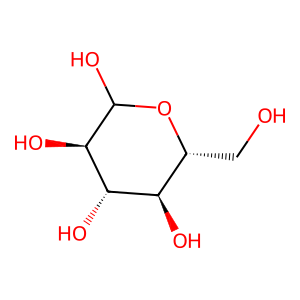
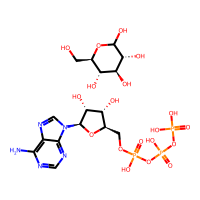

In [26]:
#@title Helper to fetch SMILES strings of reactions using substrate SMILES
#@markdown This code takes as input an enzyme sequence and a substrate SMILES to
#@markdown find hits from BRENDA and SABIO-RK which match with the enzyme sequence
#@markdown and substrate SMILES and list its coreactants
# prediction_type = "kcat" #@param ["kcat", "Km", "Ki"]
parameter = parameter.lower()

import time
import pandas as pd
import numpy as np
from IPython.display import Image, display
from rdkit import Chem
from rdkit.Chem.Draw.IPythonConsole import ShowMols

sequence = 'MLDDRARMEAAKKEKVEQILAEFQLQEEDLKKVMRRMQKEMDRGLRLETHEEASVKMLPTYVRSTPEGSEVGDFLSLDLGGTNFRVMLVKVGEGEEGQWSVKTKHQMYSIPEDAMTGTAEMLFDYISECISDFLDKHQMKHKKLPLGFTFSFPVRHEDIDKGILLNWTKGFKASGAEGNNVVGLLRDAIKRRGDFEMDVVAMVNDTVATMISCYYEDHQCEVGMIVGTGCNACYMEEMQNVELVEGDEGRMCVNTEWGAFGDSGELDEFLLEYDRLVDESSANPGQQLYEKLIGGKYMGELVRLVLLRLVDENLLFHGEASEQLRTRGAFETRFVSQVESDTGDRKQIYNILSTLGLRPSTTDCDIVRRACESVSTRAAHMCSAGLAGVINRMRESRSEDVMRITVGVDGSVYKLHPSFKERFHASVRRLTPSCEITFIESEEGSGRGAALVSAVACKKACMLGQ' #@param {type:"string"}
Substrate_SMILES = "C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O " #@param {type:"string"}

matched_seq = find_matches_brenda_seq(brenda_df, sequence)

from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, HTML

def mol_to_img_str(mol, size=(200, 200)):
    img = Draw.MolToImage(mol, size=size)
    import io
    import base64
    buffered = io.BytesIO()
    img.save(buffered, format="PNG")
    return base64.b64encode(buffered.getvalue()).decode()

def create_table_html(rows, headers):
    table_html = """
    <table style="border-collapse: collapse; width: 100%; margin-bottom: 20px;">
      <tr>
    """
    for header in headers:
        table_html += f'<th style="border: 1px solid black; padding: 8px; text-align: center;">{header}</th>'
    table_html += "</tr>"

    for row in rows:
        table_html += "<tr>"
        for cell in row:
            table_html += f'<td style="border: 1px solid black; padding: 8px; text-align: center;">{cell}</td>'
        table_html += "</tr>"

    table_html += "</table>"
    return table_html

# Assume this is your input SMILES for the query molecule
query_smiles = Substrate_SMILES
query_mol = Chem.MolFromSmiles(query_smiles)
query_img_str = mol_to_img_str(query_mol, size=(300, 300))

# Create query table
query_table = create_table_html([
    ["Query Molecule", "SMILES"],
    [f'<img src="data:image/png;base64,{query_img_str}" alt="Query Molecule">', query_smiles]
], ["", ""])

# Create matched reactions table
list_of_matched_rxns = list(set(matched_seq.reaction_smiles))
matched_rows = []

for i, rxn in enumerate(list_of_matched_rxns):
    reactant_smi = rxn.split('>>')[0]
    mol = Chem.MolFromSmiles(reactant_smi)
    img_str = mol_to_img_str(mol)

    matched_rows.append([
        str(i+1),
        f'<img src="data:image/png;base64,{img_str}" alt="Molecule {i+1}">',
        reactant_smi
    ])

matched_table = create_table_html(matched_rows, ["Index", "Reactants", "Concatenated reactants SMILES"])

# Combine both tables and display
full_html = f"""
<h2>Query Molecule</h2>
{query_table}
<h2>Matched Reactions</h2>
{matched_table}
"""

display(HTML(full_html))

